# Performance of Concrete Incorporating Super-Absorbing Polymers
## ML PIPELINE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

### Scikit-Learn modules

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [9]:
file_path = r"C:\Users\gs828\FINAL_PROJECTS\SAP_ML_Project\Data\SAP_M30_RESULTS.csv"

In [10]:
df = pd.read_csv(file_path)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sample_No         132 non-null    int64  
 1   SAP_%             132 non-null    float64
 2   W_C_Ratio         132 non-null    float64
 3   Weight_g          132 non-null    float64
 4   Area_mm2          132 non-null    int64  
 5   Peak_Load_kN      132 non-null    float64
 6   Final_Load_kN     132 non-null    float64
 7   Peak_Stress_MPa   132 non-null    float64
 8   Final_Stress_MPa  132 non-null    float64
 9   Slump_mm          132 non-null    int64  
 10  Age_days          132 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 11.5 KB


In [12]:
df.shape

(132, 11)

In [13]:
df.columns

Index(['Sample_No', 'SAP_%', 'W_C_Ratio', 'Weight_g', 'Area_mm2',
       'Peak_Load_kN', 'Final_Load_kN', 'Peak_Stress_MPa', 'Final_Stress_MPa',
       'Slump_mm', 'Age_days'],
      dtype='object')

In [14]:
df.dtypes

Sample_No             int64
SAP_%               float64
W_C_Ratio           float64
Weight_g            float64
Area_mm2              int64
Peak_Load_kN        float64
Final_Load_kN       float64
Peak_Stress_MPa     float64
Final_Stress_MPa    float64
Slump_mm              int64
Age_days              int64
dtype: object

In [15]:
df.describe()

,Sample_No,SAP_%,W_C_Ratio,Weight_g,Area_mm2,Peak_Load_kN,Final_Load_kN,Peak_Stress_MPa,Final_Stress_MPa,Slump_mm,Age_days
count,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,66.500000,0.340909,0.383864,2471.597727,10391.007576,247.158333,247.197727,23.722955,23.726818,98.636364,38.659091
std,38.249183,0.198834,0.033513,118.671027,595.492708,88.581377,83.924080,7.942678,7.460052,70.318498,36.005053
min,1.000000,0.000000,0.340000,2050.500000,9500.000000,102.600000,116.100000,8.800000,10.400000,10.000000,7.000000
25%,33.750000,0.200000,0.360000,2429.750000,9999.000000,186.875000,197.050000,17.987500,19.250000,40.000000,7.000000
50%,66.500000,0.400000,0.380000,2477.250000,10200.000000,228.950000,223.650000,22.680000,21.975000,70.000000,28.000000
75%,99.250000,0.450000,0.400000,2530.250000,10531.500000,294.425000,287.900000,28.425000,27.770000,170.000000,90.000000
max,132.000000,0.600000,0.450000,2768.000000,12100.000000,517.400000,528.000000,46.490000,44.860000,230.000000,90.000000


In [16]:
df.isnull().sum()

Sample_No           0
SAP_%               0
W_C_Ratio           0
Weight_g            0
Area_mm2            0
Peak_Load_kN        0
Final_Load_kN       0
Peak_Stress_MPa     0
Final_Stress_MPa    0
Slump_mm            0
Age_days            0
dtype: int64

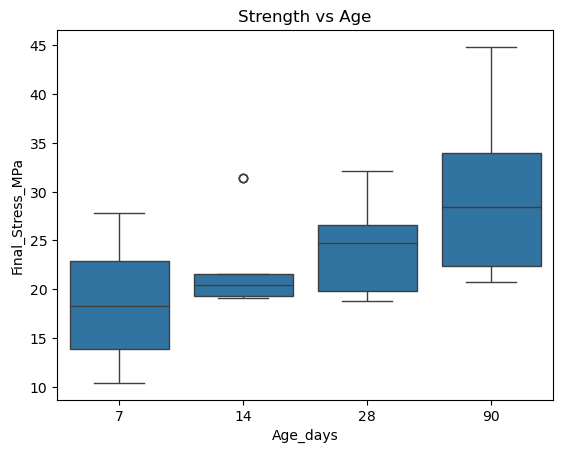

In [17]:
sns.boxplot(x='Age_days', y='Final_Stress_MPa', data=df)
plt.title("Strength vs Age")
plt.show()

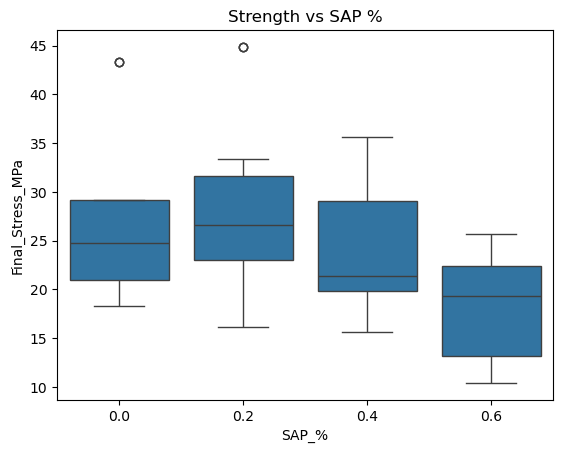

In [18]:
sns.boxplot(x='SAP_%', y='Final_Stress_MPa', data=df)
plt.title("Strength vs SAP %")
plt.show()

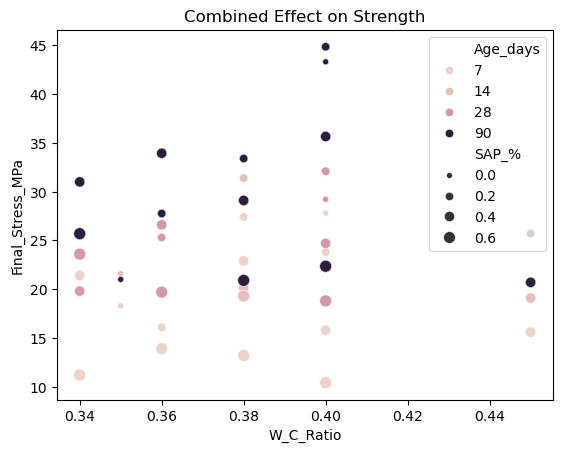

In [19]:
sns.scatterplot(
    x='W_C_Ratio',
    y='Final_Stress_MPa',
    hue='Age_days',
    size='SAP_%',
    data=df
)

plt.title("Combined Effect on Strength")
plt.show()

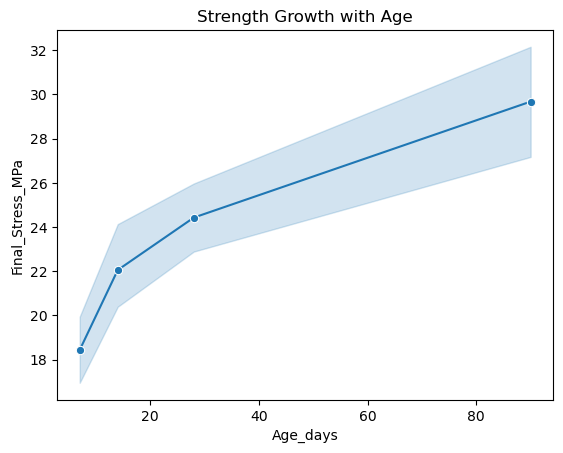

In [20]:
sns.lineplot(x='Age_days', y='Final_Stress_MPa', data=df, marker='o')
plt.title("Strength Growth with Age")
plt.show()

In [21]:
df.groupby('Age_days')['Final_Stress_MPa'].mean()

Age_days
7     18.433333
14    22.050000
28    24.422222
90    29.670000
Name: Final_Stress_MPa, dtype: float64

In [22]:
df.groupby('SAP_%')['Final_Stress_MPa'].mean()

SAP_%
0.0    26.870000
0.2    27.293333
0.4    23.746667
0.6    18.094545
Name: Final_Stress_MPa, dtype: float64

In [23]:
df.groupby('W_C_Ratio')['Final_Stress_MPa'].mean()

W_C_Ratio
0.34    22.115000
0.35    20.300000
0.36    22.887500
0.38    24.188889
0.40    27.399167
0.45    20.133333
Name: Final_Stress_MPa, dtype: float64

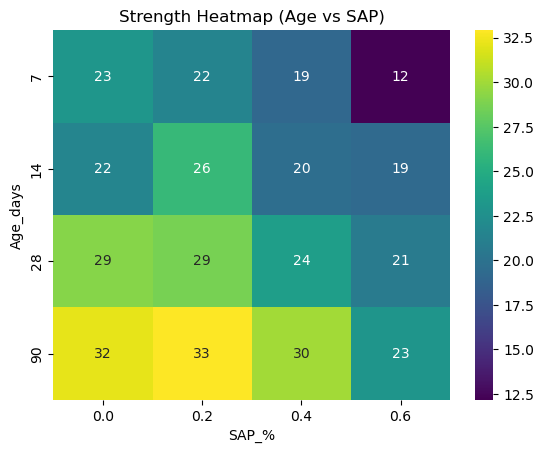

In [24]:
pivot = df.pivot_table(
    values='Final_Stress_MPa',
    index='Age_days',
    columns='SAP_%',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, cmap='viridis')
plt.title("Strength Heatmap (Age vs SAP)")
plt.show()

Feature Importance (Correlation-based):
Age_days     0.594004
SAP_%        0.439921
Slump_mm     0.298306
Area_mm2     0.151911
Weight_g     0.105538
W_C_Ratio    0.018470
Name: Final_Stress_MPa, dtype: float64


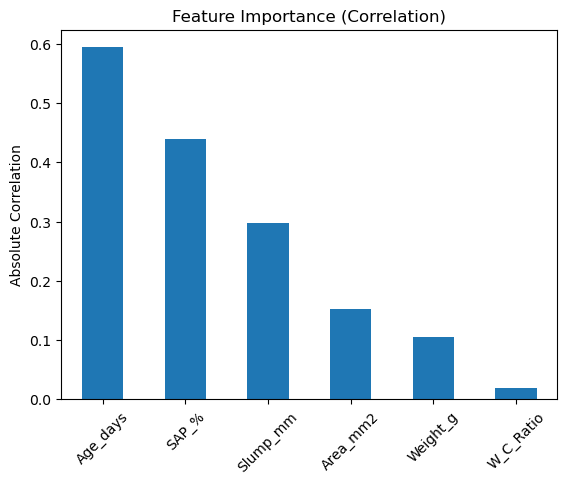

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Select features + target
features = ['SAP_%', 'W_C_Ratio', 'Age_days', 'Slump_mm', 'Weight_g', 'Area_mm2']
target = 'Final_Stress_MPa'

# Compute correlation
corr = df[features + [target]].corr()

# Get correlation with target
target_corr = corr[target].drop(target)

# Sort by absolute value
importance = target_corr.abs().sort_values(ascending=False)

# Print ranking
print("Feature Importance (Correlation-based):")
print(importance)

# Plot
importance.plot(kind='bar', title='Feature Importance (Correlation)')
plt.ylabel("Absolute Correlation")
plt.xticks(rotation=45)
plt.show()

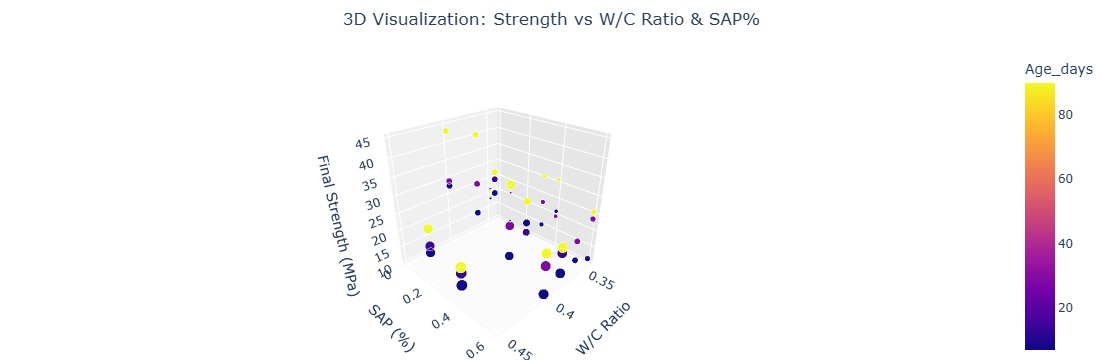

In [26]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='W_C_Ratio',
    y='SAP_%',
    z='Final_Stress_MPa',
    color='Age_days',
    size='Slump_mm',
    size_max=18,   # control bubble size
    opacity=0.8,
    title='3D Visualization: Strength vs W/C Ratio & SAP%'
)

# Improve layout & axis clarity
fig.update_layout(
    scene=dict(
        xaxis=dict(
            title='W/C Ratio',
            backgroundcolor="rgb(230, 230, 230)",
            gridcolor="white",
            showbackground=True,
            zerolinecolor="white",
        ),
        yaxis=dict(
            title='SAP (%)',
            backgroundcolor="rgb(240, 240, 240)",
            gridcolor="white",
            showbackground=True,
            zerolinecolor="white",
        ),
        zaxis=dict(
            title='Final Strength (MPa)',
            backgroundcolor="rgb(250, 250, 250)",
            gridcolor="white",
            showbackground=True,
            zerolinecolor="white",
        ),
        aspectmode='cube'   # equal scaling for all axes
    ),
    
    margin=dict(l=0, r=0, b=0, t=50),
    title_x=0.5
)

# Better camera angle
fig.update_scenes(
    camera=dict(
        eye=dict(x=1.6, y=1.6, z=1.2)
    )
)

fig.show()

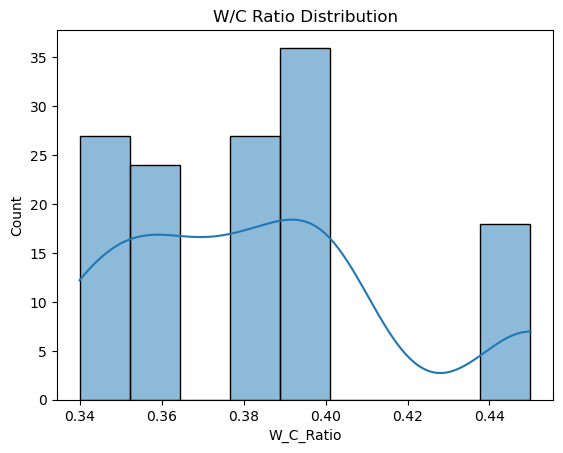

In [27]:
sns.histplot(df['W_C_Ratio'], kde=True)
plt.title("W/C Ratio Distribution")
plt.show()

# Exploratory Data Analysis (EDA)

In [28]:
# ==========================================
# 1. SETUP AND CONFIGURATION
# ==========================================
# Set a beautiful, modern theme for all our plots
sns.set_theme(style="whitegrid", context="talk")

OUTPUT_DIR = "EDA_Visualizations"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Visualizations will be saved to the '{OUTPUT_DIR}' folder.\n")

Visualizations will be saved to the 'EDA_Visualizations' folder.



Generating Feature Distributions...


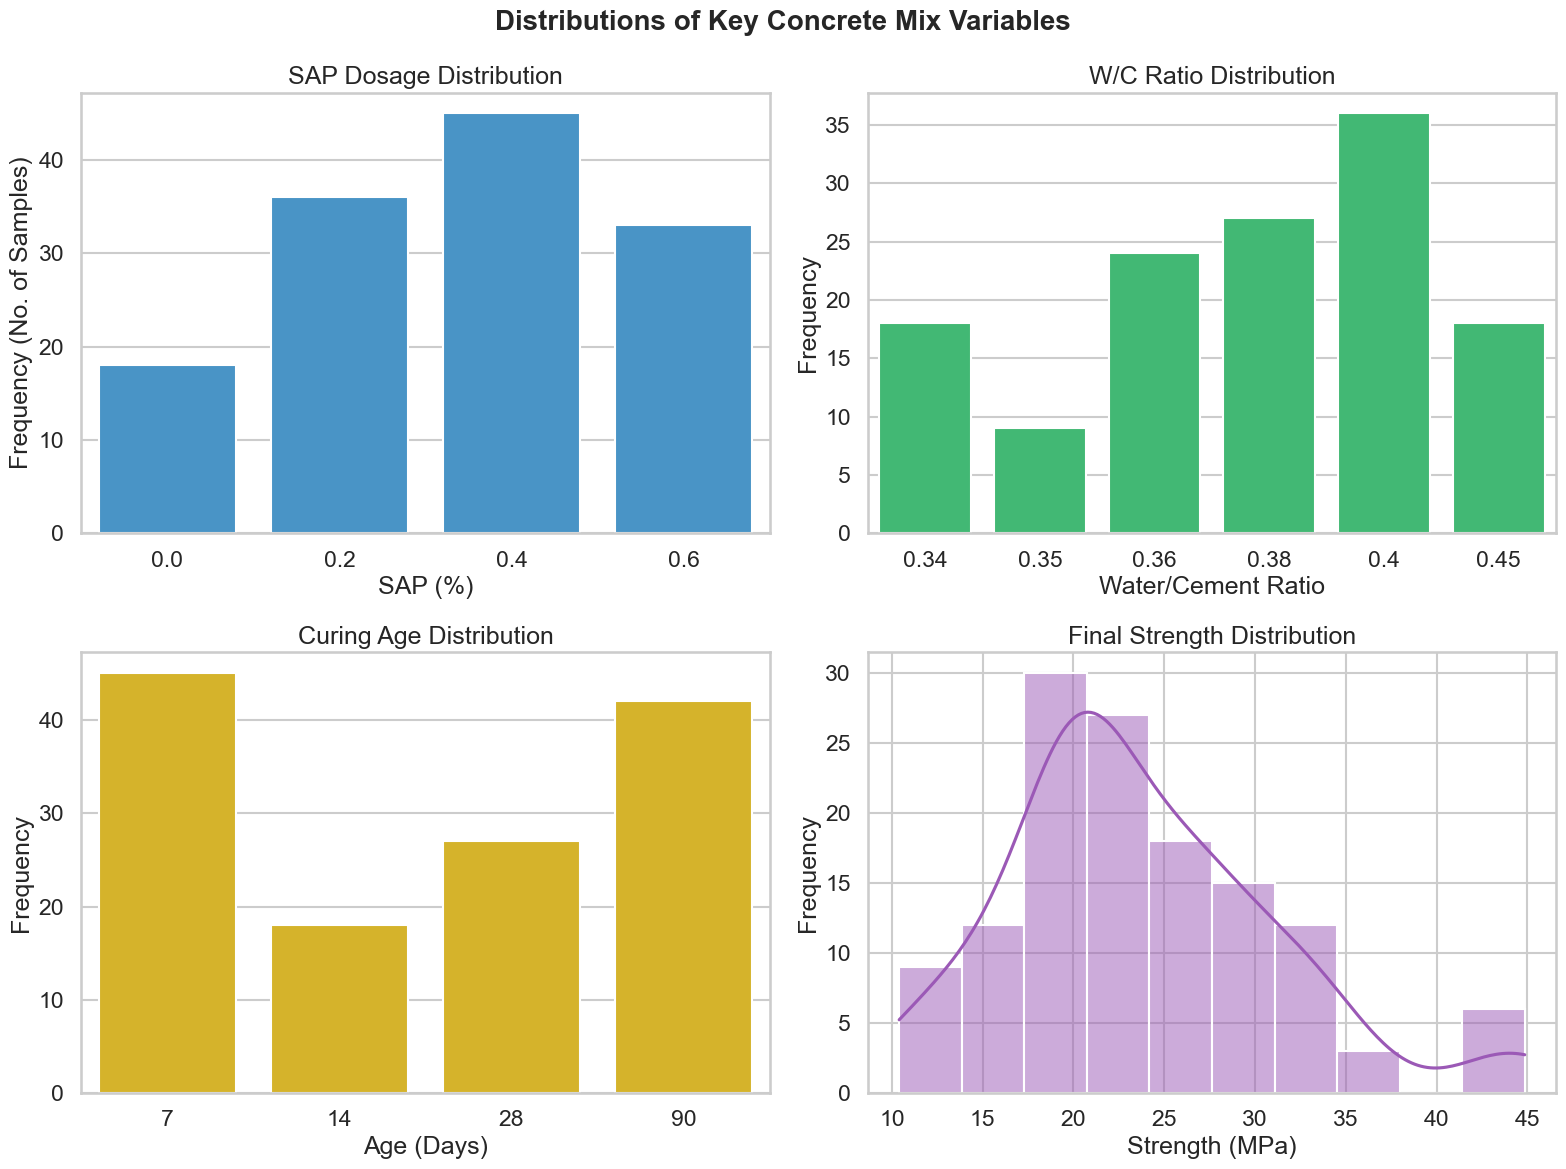

In [29]:
# ========================================== 
# 2. FEATURE DISTRIBUTIONS (Histograms) 
# ==========================================

print("Generating Feature Distributions...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Distributions of Key Concrete Mix Variables", fontsize=20, fontweight='bold')

# 1. SAP Dosage (Discrete Values)
sns.countplot(x=df['SAP_%'], ax=axes[0, 0], color='#3498db')
axes[0, 0].set_title('SAP Dosage Distribution')
axes[0, 0].set_xlabel('SAP (%)')
axes[0, 0].set_ylabel('Frequency (No. of Samples)')

# 2. W/C Ratio
sns.countplot(x=df['W_C_Ratio'], ax=axes[0, 1], color='#2ecc71')
axes[0, 1].set_title('W/C Ratio Distribution')
axes[0, 1].set_xlabel('Water/Cement Ratio')
axes[0, 1].set_ylabel('Frequency')

# 3. Curing Age
sns.countplot(x=df['Age_days'], ax=axes[1, 0], color='#f1c40f')
axes[1, 0].set_title('Curing Age Distribution')
axes[1, 0].set_xlabel('Age (Days)')
axes[1, 0].set_ylabel('Frequency')

# 4. Final Strength (continuous → histogram OK)
sns.histplot(df['Final_Stress_MPa'], bins=10, kde=True, ax=axes[1, 1], color='#9b59b6')
axes[1, 1].set_title('Final Strength Distribution')
axes[1, 1].set_xlabel('Strength (MPa)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/2_feature_distributions_corrected.png", dpi=300)
plt.show()

Generating Strength Development Curve...


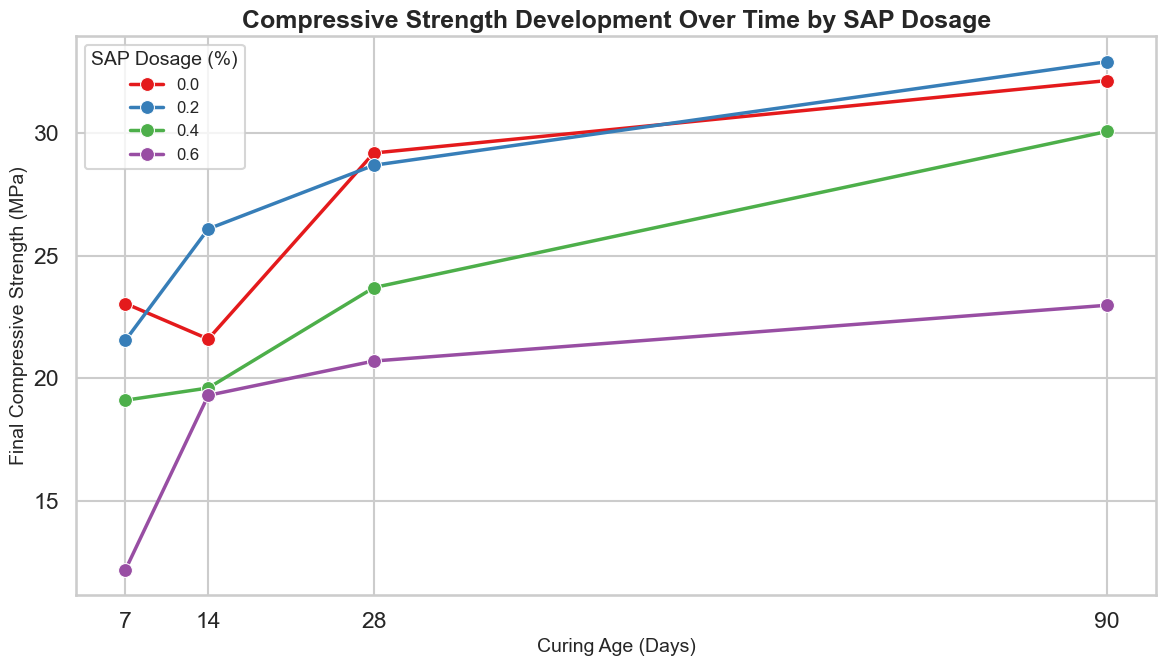

In [30]:
# ==========================================
# 3. STRENGTH DEVELOPMENT OVER TIME
# ==========================================
print("Generating Strength Development Curve...")
plt.figure(figsize=(12, 7))

# Line plot showing how strength grows as concrete ages, separated by SAP dosage
sns.lineplot(
    data=df, 
    x='Age_days', 
    y='Final_Stress_MPa', 
    hue='SAP_%', 
    marker='o', 
    markersize=10,
    linewidth=2.5,
    errorbar=None, # Removes error bands to keep lines clean
    palette='Set1'
)

plt.title('Compressive Strength Development Over Time by SAP Dosage', fontsize=18, fontweight='bold')
plt.xlabel('Curing Age (Days)', fontsize=14)
plt.ylabel('Final Compressive Strength (MPa)', fontsize=14)
plt.xticks([7, 14, 28, 90])
plt.legend(title='SAP Dosage (%)', fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/3_strength_vs_age.png", dpi=300)

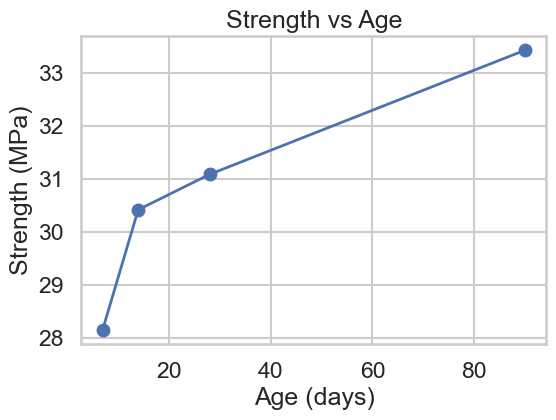

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Age range
age_range = [7, 14, 28, 90]

# Create input data
temp_df = pd.DataFrame({
    'SAP_%': 0.2,
    'W_C_Ratio': 0.38,
    'Weight_g': 2500,
    'Area_mm2': 10000,
    'Slump_mm': 70,
    'Age_days': age_range
})

# Predict
pred = best_model.predict(temp_df)

# Plot
plt.figure(figsize=(6,4))
plt.plot(age_range, pred, marker='o', linewidth=2)
plt.xlabel("Age (days)")
plt.ylabel("Strength (MPa)")
plt.title("Strength vs Age")
plt.grid(True)

# Save for PPT
plt.savefig("strength_vs_age.png", dpi=300, bbox_inches='tight')
plt.show()

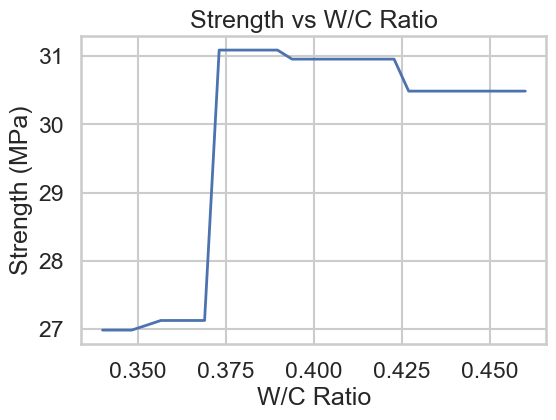

In [44]:
# W/C range
wc_range = np.linspace(0.34, 0.46, 30)

temp_df = pd.DataFrame({
    'SAP_%': 0.2,
    'W_C_Ratio': wc_range,
    'Weight_g': 2500,
    'Area_mm2': 10000,
    'Slump_mm': 70,
    'Age_days': 28
})

pred = best_model.predict(temp_df)

plt.figure(figsize=(6,4))
plt.plot(wc_range, pred, linewidth=2)
plt.xlabel("W/C Ratio")
plt.ylabel("Strength (MPa)")
plt.title("Strength vs W/C Ratio")
plt.grid(True)

plt.savefig("strength_vs_wc.png", dpi=300, bbox_inches='tight')
plt.show()

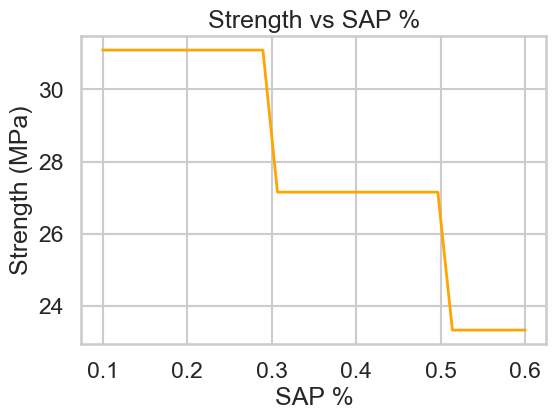

In [45]:
# SAP range
sap_range = np.linspace(0.1, 0.6, 30)

temp_df = pd.DataFrame({
    'SAP_%': sap_range,
    'W_C_Ratio': 0.38,
    'Weight_g': 2500,
    'Area_mm2': 10000,
    'Slump_mm': 70,
    'Age_days': 28
})

pred = best_model.predict(temp_df)

plt.figure(figsize=(6,4))
plt.plot(sap_range, pred, color='orange', linewidth=2)
plt.xlabel("SAP %")
plt.ylabel("Strength (MPa)")
plt.title("Strength vs SAP %")
plt.grid(True)

plt.savefig("strength_vs_sap.png", dpi=300, bbox_inches='tight')
plt.show()

Generating 7-Day Target Strength Analysis...


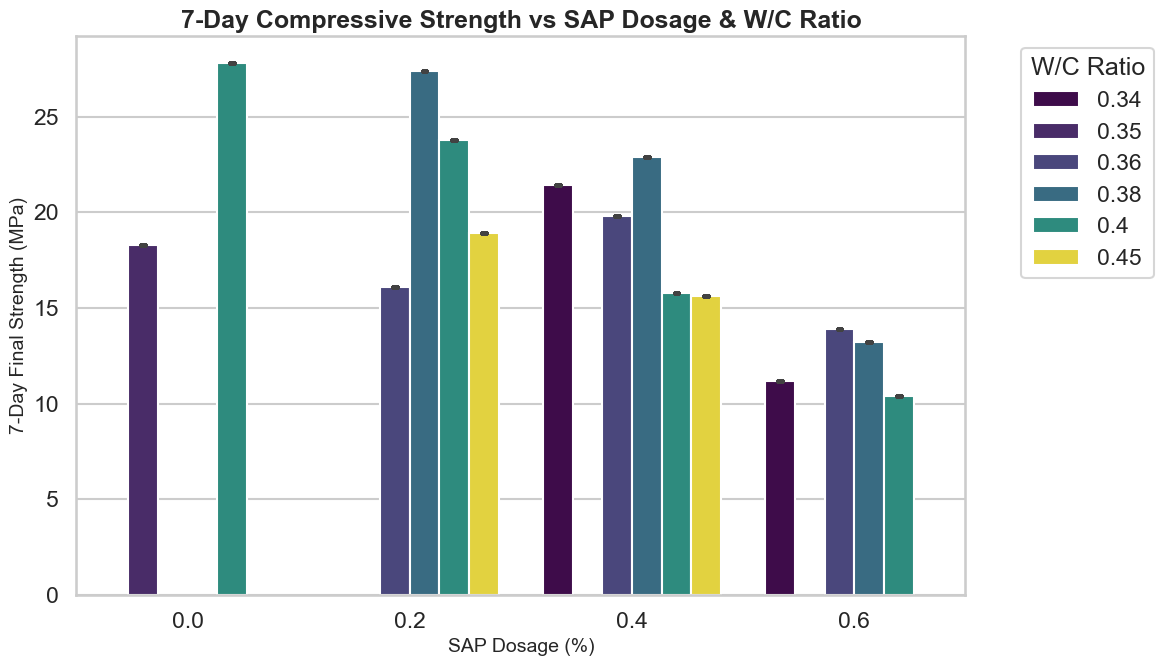

In [34]:
# ==========================================
# 4. 7-DAY STRENGTH ANALYSIS (Early Stage Metric)
# ==========================================
print("Generating 7-Day Target Strength Analysis...")
# Filter data to only look at 7-day curing
df_7_days = df[df['Age_days'] == 7]

plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_7_days, 
    x='SAP_%', 
    y='Final_Stress_MPa', 
    hue='W_C_Ratio', 
    palette='viridis',
    capsize=0.1
)

plt.title('7-Day Compressive Strength vs SAP Dosage & W/C Ratio', fontsize=18, fontweight='bold')
plt.xlabel('SAP Dosage (%)', fontsize=14)
plt.ylabel('7-Day Final Strength (MPa)', fontsize=14)
# Move legend outside the plot
plt.legend(title='W/C Ratio', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/4_strength_7days.png", dpi=300)

Generating 14-Day Target Strength Analysis...
Saved 14-day strength analysis!


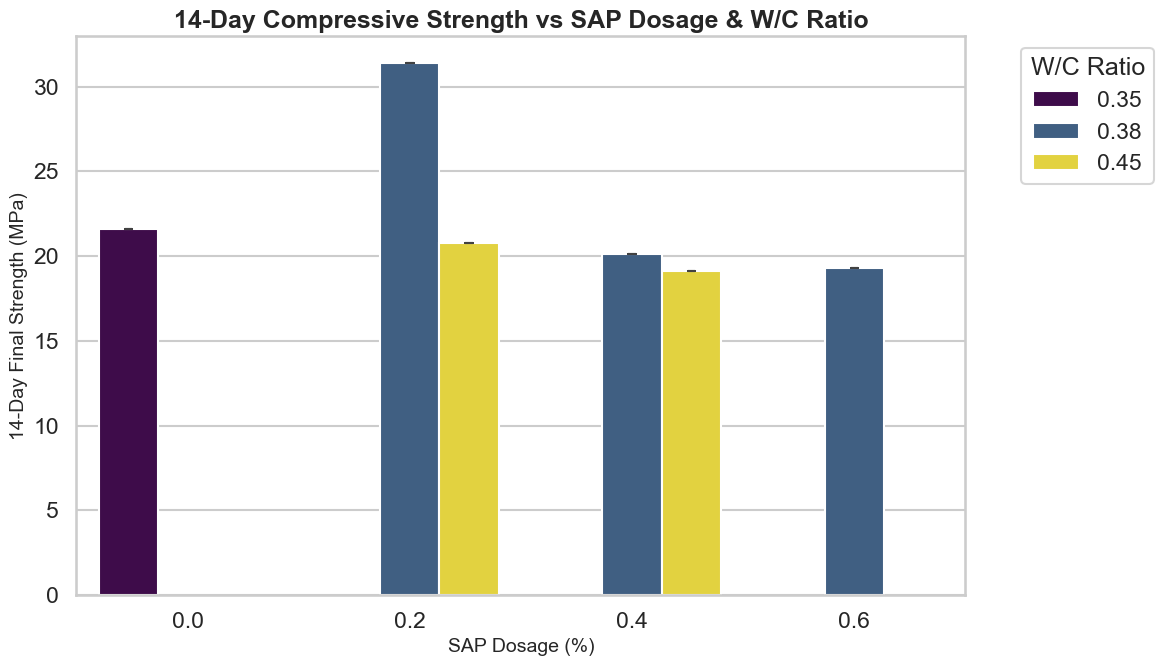

In [35]:
# ==========================================
# 4. 14-DAY STRENGTH ANALYSIS (Early Strength Metric)
# ==========================================
print("Generating 14-Day Target Strength Analysis...")
# Filter data to only look at 14-day curing
df_14_days = df[df['Age_days'] == 14]

plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_14_days, 
    x='SAP_%', 
    y='Final_Stress_MPa', 
    hue='W_C_Ratio', 
    palette='viridis',
    capsize=0.1,
    err_kws={'linewidth': 1.5} # Updated to modern seaborn parameter for error bars
)

plt.title('14-Day Compressive Strength vs SAP Dosage & W/C Ratio', fontsize=18, fontweight='bold')
plt.xlabel('SAP Dosage (%)', fontsize=14)
plt.ylabel('14-Day Final Strength (MPa)', fontsize=14)
# Move legend outside the plot
plt.legend(title='W/C Ratio', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
# Save with a new file name indicating 14 days
plt.savefig(f"{OUTPUT_DIR}/4_strength_14days.png", dpi=300)


print("Saved 14-day strength analysis!")

Generating 28-Day Target Strength Analysis...


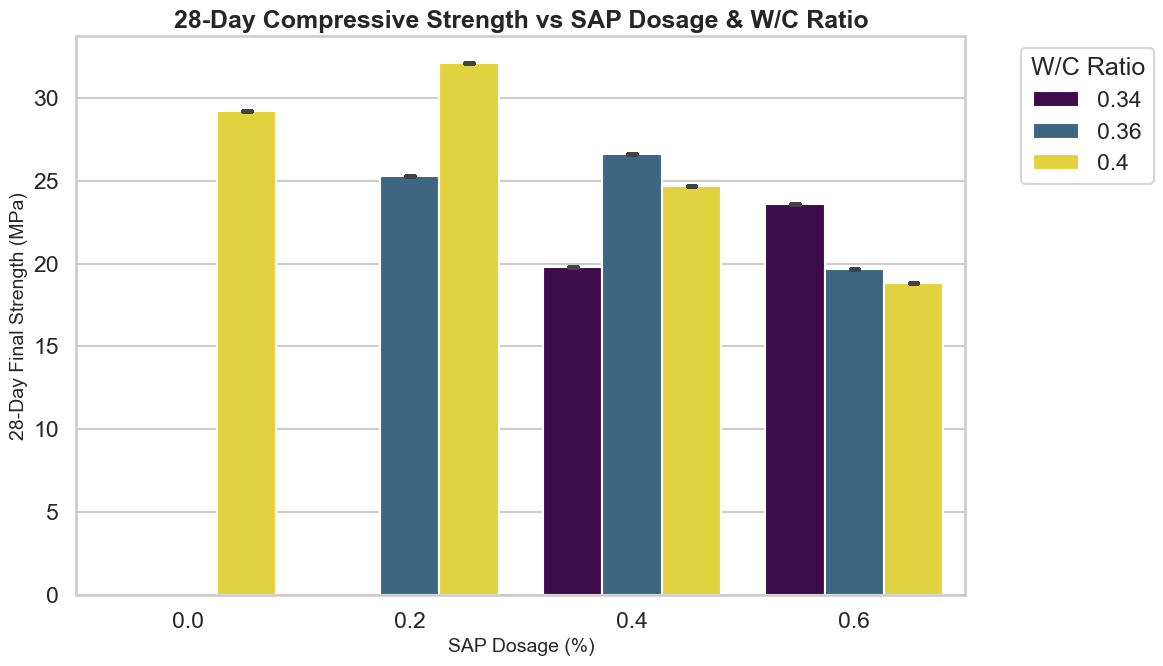

In [36]:
# ==========================================
# 4. 28-DAY STRENGTH ANALYSIS (Crucial Metric)
# ==========================================
print("Generating 28-Day Target Strength Analysis...")
# Filter data to only look at 28-day curing
df_28_days = df[df['Age_days'] == 28]

plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_28_days, 
    x='SAP_%', 
    y='Final_Stress_MPa', 
    hue='W_C_Ratio', 
    palette='viridis',
    capsize=0.1
)

plt.title('28-Day Compressive Strength vs SAP Dosage & W/C Ratio', fontsize=18, fontweight='bold')
plt.xlabel('SAP Dosage (%)', fontsize=14)
plt.ylabel('28-Day Final Strength (MPa)', fontsize=14)
# Move legend outside the plot
plt.legend(title='W/C Ratio', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/4_strength_28days.png", dpi=300)


Generating 90-Day Target Strength Analysis...
Saved 90-day strength analysis as '4_strength_90days.png'


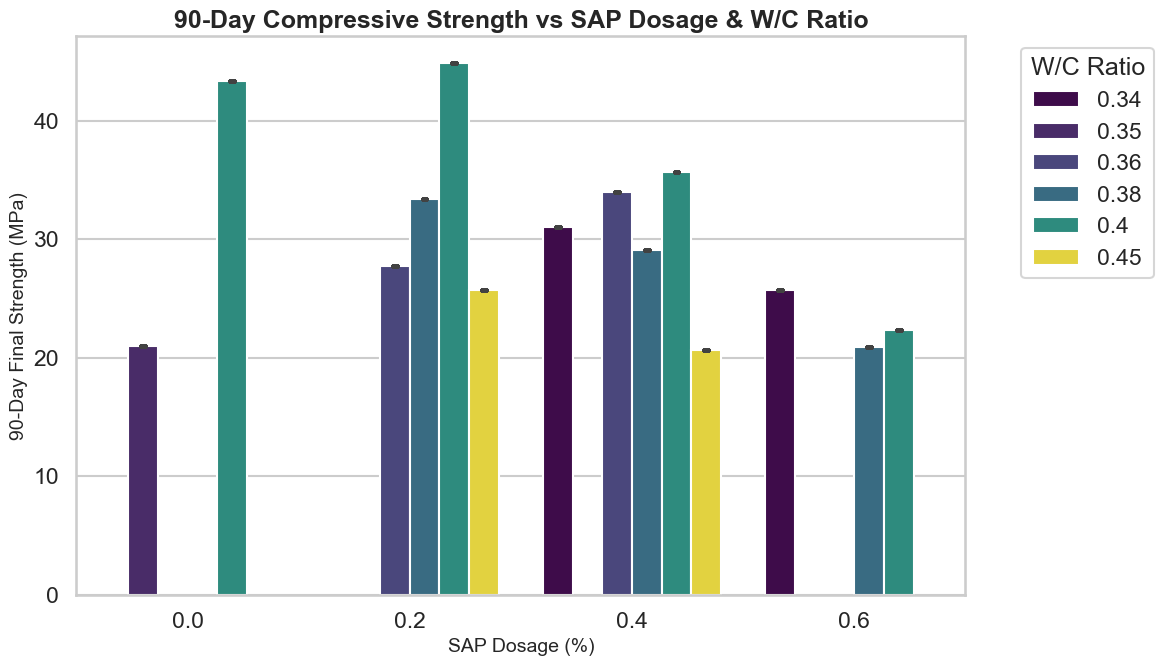

In [37]:
# ==========================================
# 4. 90-DAY STRENGTH ANALYSIS (Long-Term Metric)
# ==========================================
print("Generating 90-Day Target Strength Analysis...")
# Filter data to only look at 90-day curing (Long-term internal curing effects)
df_90_days = df[df['Age_days'] == 90]

plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_90_days, 
    x='SAP_%', 
    y='Final_Stress_MPa', 
    hue='W_C_Ratio', 
    palette='viridis',
    capsize=0.1
)

plt.title('90-Day Compressive Strength vs SAP Dosage & W/C Ratio', fontsize=18, fontweight='bold')
plt.xlabel('SAP Dosage (%)', fontsize=14)
plt.ylabel('90-Day Final Strength (MPa)', fontsize=14)
# Move legend outside the plot
plt.legend(title='W/C Ratio', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
# Updated filename to reflect 90 days
plt.savefig(f"{OUTPUT_DIR}/4_strength_90days.png", dpi=300)


print("Saved 90-day strength analysis as '4_strength_90days.png'")

Generating Workability (Slump) Scatter Plot...


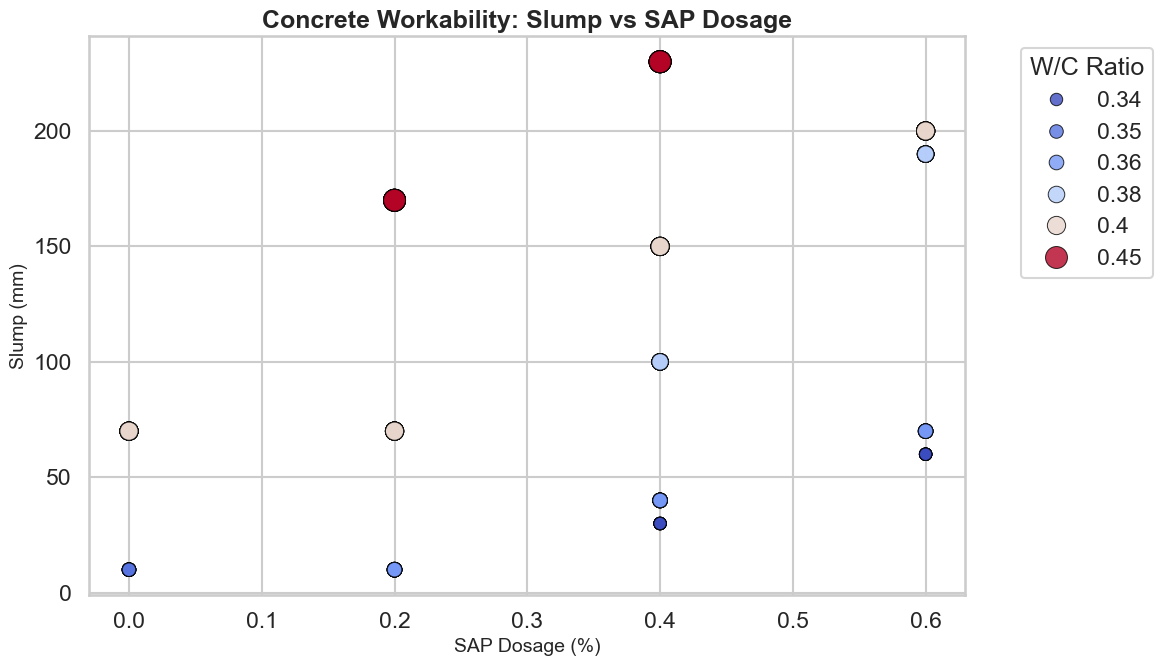

In [38]:
# ==========================================
# 5. WORKABILITY (SLUMP) ANALYSIS
# ==========================================
print("Generating Workability (Slump) Scatter Plot...")
plt.figure(figsize=(12, 7))

# Drop rows where Slump is missing for this specific plot
df_slump = df.dropna(subset=['Slump_mm'])

sns.scatterplot(
    data=df_slump, 
    x='SAP_%', 
    y='Slump_mm', 
    hue='W_C_Ratio', 
    size='W_C_Ratio', 
    sizes=(80, 250), # Adjust dot sizes
    palette='coolwarm',
    alpha=0.8,
    edgecolor='black'
)

plt.title('Concrete Workability: Slump vs SAP Dosage', fontsize=18, fontweight='bold')
plt.xlabel('SAP Dosage (%)', fontsize=14)
plt.ylabel('Slump (mm)', fontsize=14)
plt.legend(title='W/C Ratio', bbox_to_anchor=(1.05, 1), loc='upper left', scatterpoints=1)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/5_workability_slump.png", dpi=300)

Generating Pairplot (This might take a few seconds)...

✅ All EDA visualizations successfully generated and saved in the 'EDA_Visualizations' folder!


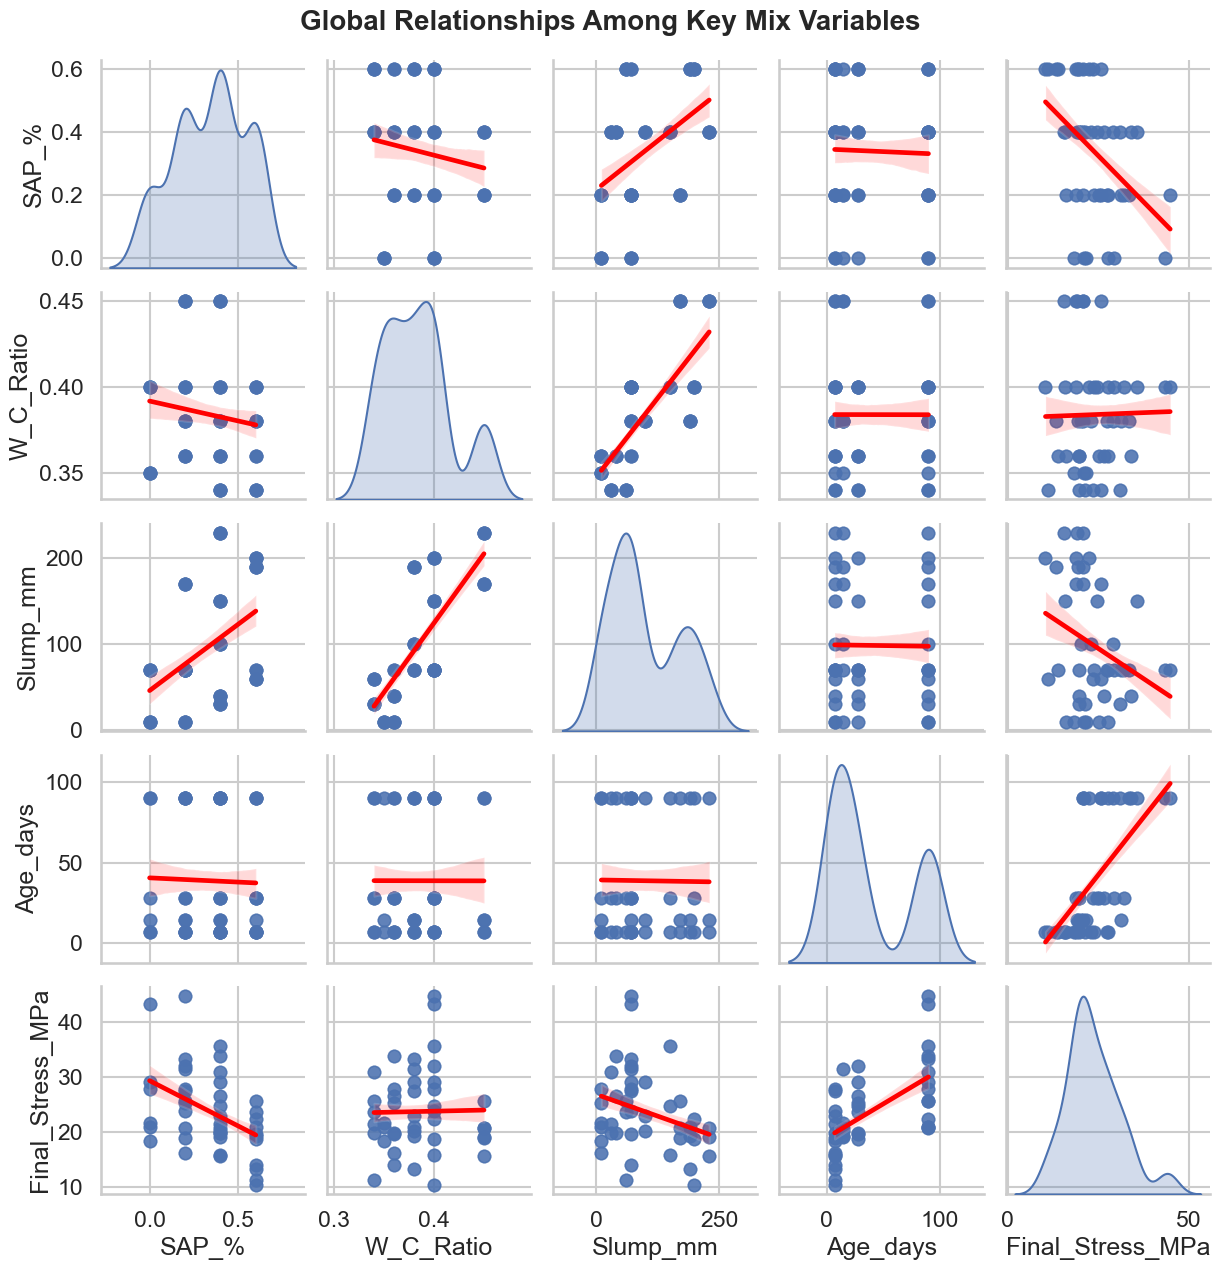

In [39]:
# ==========================================
# 6. GLOBAL RELATIONSHIPS (PAIRPLOT)
# ==========================================
print("Generating Pairplot (This might take a few seconds)...")
# Select only the most important continuous variables
key_features = ['SAP_%', 'W_C_Ratio', 'Slump_mm', 'Age_days', 'Final_Stress_MPa']
df_subset = df[key_features].dropna()

# Create a pairplot with a linear regression line (kind='reg') to easily spot trends
pair_grid = sns.pairplot(
    df_subset, 
    diag_kind='kde', 
    kind='reg', 
    plot_kws={'line_kws': {'color': 'red'}, 'scatter_kws': {'alpha': 0.5}}
)

pair_grid.fig.suptitle('Global Relationships Among Key Mix Variables', y=1.02, fontsize=20, fontweight='bold')

plt.savefig(f"{OUTPUT_DIR}/6_pairplot_relationships.png", dpi=300)


print("\n✅ All EDA visualizations successfully generated and saved in the 'EDA_Visualizations' folder!")

Generating Correlation Heatmap...
Saved EDA correlation heatmap as '7_correlation_heatmap.png'


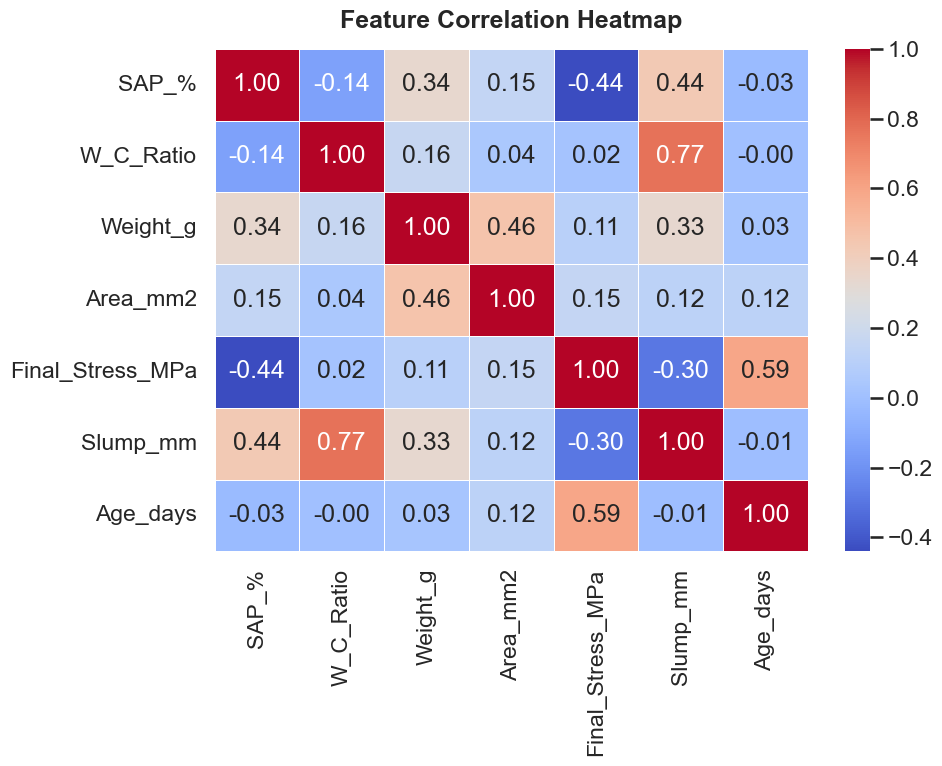

In [40]:
# ==========================================
# 7. Plot Correlation Heatmap
# ==========================================
print("Generating Correlation Heatmap...")

# Drop columns that are either identifiers or intermediate test results
drop_cols = ['Sample_No', 'Peak_Load_kN', 'Final_Load_kN', 'Peak_Stress_MPa']

# Check if 'Sample_N' exists instead of 'Sample_No' (based on some of your CSVs)
if 'Sample_No' not in df.columns and 'Sample_N' in df.columns:
    drop_cols[0] = 'Sample_N'

# Drop the columns, ignoring errors if some are already missing
df_ml = df.drop(columns=drop_cols, errors='ignore')

# Create the heatmap
plt.figure(figsize=(10, 8)) # Slightly larger for better readability
sns.heatmap(df_ml.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=18, fontweight='bold', pad=15)
plt.tight_layout()

# CORRECTED SAVEFIG LINE: Added the slash and fixed the quotes
plt.savefig(f"{OUTPUT_DIR}/7_correlation_heatmap.png", dpi=300)

print("Saved EDA correlation heatmap as '7_correlation_heatmap.png'")

# FEATURE ENGINEERING & PREPROCESSING

In [32]:
# import pandas as pd
# from sklearn.impute import KNNImputer

# print("Loading dataset...")
# # Load the original dataset
# file_path = "SAP_M30_Complete_Project_Template.xlsx - Final_ML_Dataset.csv"
# df = pd.read_csv(file_path)

# # Print missing rows before imputation
# missing_indices = df[df['Slump_mm'].isnull()].index
# print(f"Found {len(missing_indices)} rows with missing Slump_mm.")

# # -----------------------------------------------------
# # FEATURE ENGINEERING: ADVANCED IMPUTATION
# # -----------------------------------------------------
# # We only use SAP_% and W_C_Ratio to predict the Slump. 
# # We DO NOT use 'Age_days' or 'Final_Stress_MPa' because Slump is measured 
# # on day 0 when the concrete is fresh. Using future data would be "Data Leakage".
# impute_cols = ['SAP_%', 'W_C_Ratio', 'Slump_mm']

# # Initialize the K-Nearest Neighbors Imputer
# # n_neighbors=3 means it looks at the 3 closest concrete mixes to guess the slump
# imputer = KNNImputer(n_neighbors=3)

# # Apply the imputer
# df_imputed = df.copy()
# df_imputed[impute_cols] = imputer.fit_transform(df[impute_cols])

# # Round the imputed slump values to the nearest whole number (e.g., 70.0 instead of 69.8)
# df_imputed['Slump_mm'] = df_imputed['Slump_mm'].round()

# # Print the newly filled values for the user to verify
# print("\n--- Imputed Values ---")
# print(df_imputed.loc[missing_indices, ['SAP_%', 'W_C_Ratio', 'Slump_mm']])

# # Save the perfectly filled data to a new CSV
# output_file = "SAP_M30_Filled_Dataset_Ready.csv"
# df_imputed.to_csv(output_file, index=False)

# print(f"\n✅ Success! The perfectly filled dataset is saved as: {output_file}")
# print("Use this new CSV for your final ML Model Training!")

In [41]:
# ==========================================
# FEATURE ENGINEERING & PREPROCESSING
# ==========================================

drop_cols = ['Sample_No', 'Peak_Load_kN', 'Final_Load_kN', 'Peak_Stress_MPa']
df_ml = df.drop(columns=drop_cols)

# Define Features (X) and Target (y)
X = df_ml.drop(columns=['Final_Stress_MPa'])
y = df_ml['Final_Stress_MPa']

# Notice that 'Slump_mm' has missing values (93 non-null out of 108).
# We will create a preprocessing pipeline to impute missing values with the median,
# and scale the features so models like Linear Regression and Gradient Boosting perform optimally.
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Fills missing Slump_mm
    ('scaler', StandardScaler())                   # Standardizes features
])

# Split data into Training and Testing Sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
# ==========================================
#  MODEL SELECTION & TRAINING
# ==========================================
print("\n--- Training Models ---")

# Define a dictionary of models to test
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
}

best_model = None
best_r2 = -float('inf')
best_model_name = ""

# Train and Evaluate each model
results = {}
for name, model in models.items():
    # Build pipeline: Preprocess -> Model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Evaluate
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
    
    # Keep track of the best model
    if r2 > best_r2:
        best_r2 = r2
        best_model = pipeline
        best_model_name = name

# Print Results
print("\n--- Model Evaluation Results ---")
for name, metrics in results.items():
    print(f"{name}:")
    print(f"  R2 Score : {metrics['R2']:.4f}")
    print(f"  RMSE     : {metrics['RMSE']:.4f}")
    print(f"  MAE      : {metrics['MAE']:.4f}\n")

print(f"🏆 Best Model: {best_model_name} (R2: {best_r2:.4f})")


--- Training Models ---

--- Model Evaluation Results ---
Linear Regression:
  R2 Score : 0.6119
  RMSE     : 4.2371
  MAE      : 3.1270

Random Forest:
  R2 Score : 0.8714
  RMSE     : 2.4392
  MAE      : 1.8855

Gradient Boosting:
  R2 Score : 0.9144
  RMSE     : 1.9901
  MAE      : 1.4265

XGBoost:
  R2 Score : 0.8697
  RMSE     : 2.4555
  MAE      : 1.6270

🏆 Best Model: Gradient Boosting (R2: 0.9144)


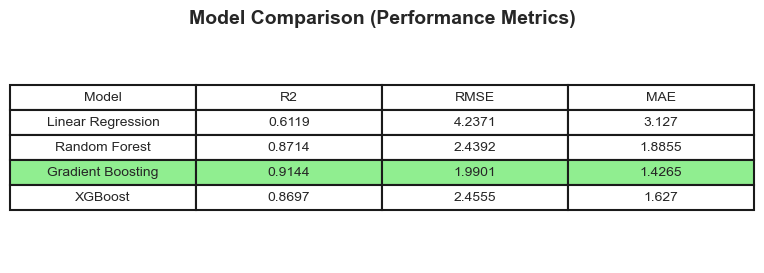

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert results dictionary to DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

# Reset index for better display
results_df.reset_index(inplace=True)
results_df.rename(columns={'index': 'Model'}, inplace=True)

# Create figure
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Highlight best model row
best_row = results_df[results_df['Model'] == best_model_name].index[0]

for i in range(len(results_df.columns)):
    table[(best_row + 1, i)].set_facecolor('#90EE90')  # light green

# Title
plt.title("Model Comparison (Performance Metrics)", fontsize=14, weight='bold')

# Save image
plt.savefig("model_comparison_table.png", bbox_inches='tight', dpi=300)

plt.show()

Saved evaluation plot as 'actual_vs_predicted.png'


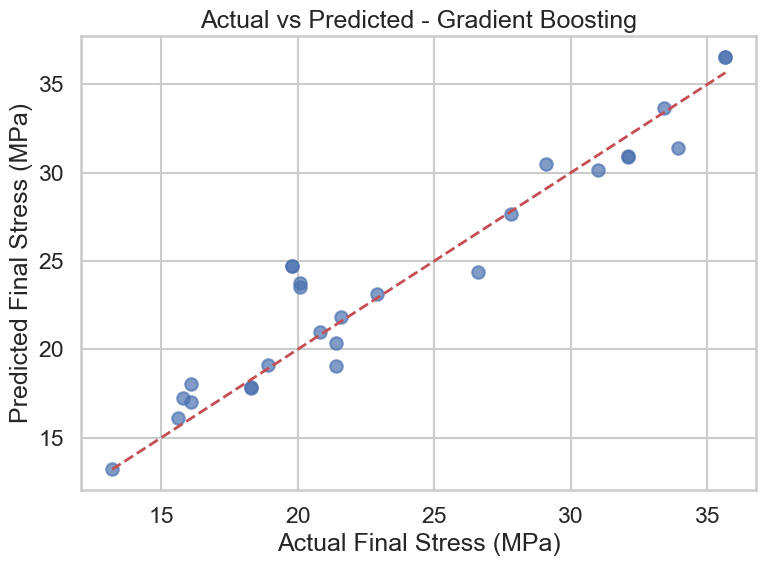

In [47]:
# ==========================================
#  MODEL EVALUATION VISUALIZATION
# ==========================================
# Plot Actual vs Predicted for the Best Model
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Final Stress (MPa)")
plt.ylabel("Predicted Final Stress (MPa)")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
print("Saved evaluation plot as 'actual_vs_predicted.png'")

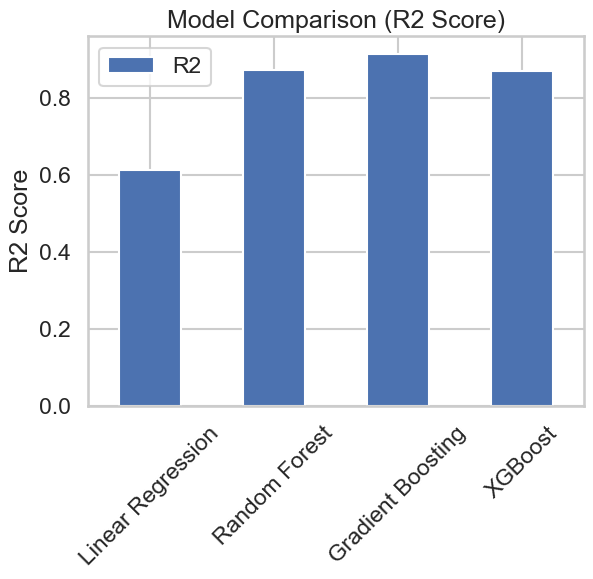

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

results_df = pd.DataFrame(results).T

results_df[['R2']].plot(kind='bar', title='Model Comparison (R2 Score)')
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.show()

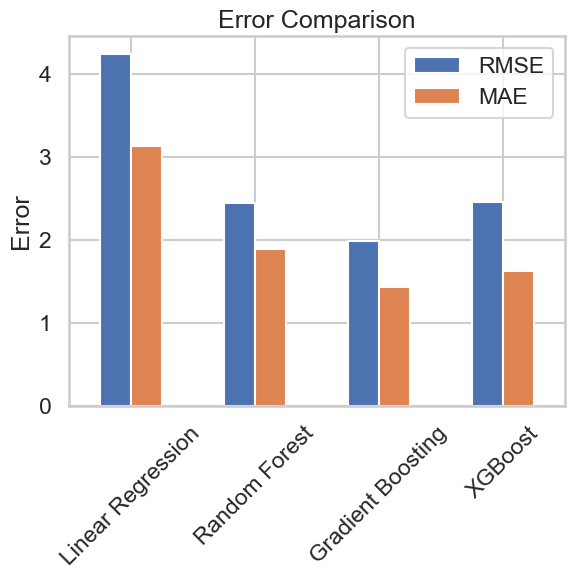

In [49]:
results_df[['RMSE', 'MAE']].plot(kind='bar', title='Error Comparison')
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.show()

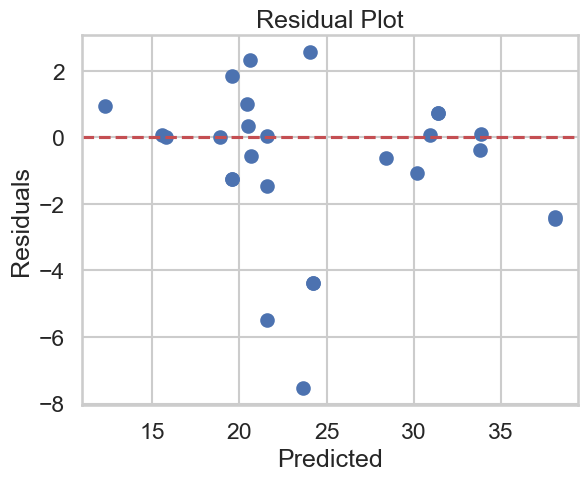

In [50]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [52]:
# ==========================================
#  SAVE MODEL FOR DEPLOYMENT
# ==========================================

import joblib

# Full path
model_path = r'C:\Users\gs828\FINAL_PROJECTS\SAP_ML_Project\ML_Model\concrete_strength_model.pkl'

# Save model
joblib.dump(best_model, model_path)

print("\n✅ Best model successfully saved at:", model_path)


✅ Best model successfully saved at: U:\College Sem study\Btech 8th sem\Major_project\ML_Model\concrete_strength_model.pkl


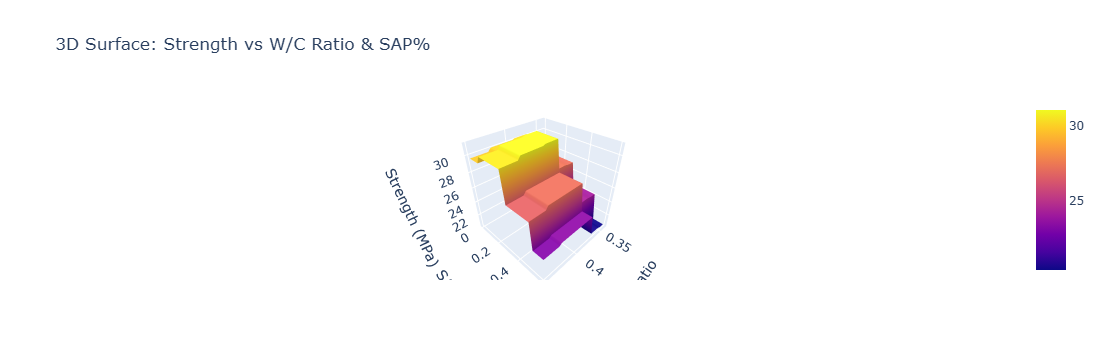

In [53]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

wc_range = np.linspace(df['W_C_Ratio'].min(), df['W_C_Ratio'].max(), 30)
sap_range = np.linspace(df['SAP_%'].min(), df['SAP_%'].max(), 30)

wc_grid, sap_grid = np.meshgrid(wc_range, sap_range)

feature_cols = X_train.columns

base_df = pd.DataFrame(columns=feature_cols)

for col in feature_cols:
    if col == 'W_C_Ratio':
        base_df[col] = wc_grid.ravel()
    elif col == 'SAP_%':
        base_df[col] = sap_grid.ravel()
    else:
        base_df[col] = df[col].median()

z_pred = best_model.predict(base_df)
z_grid = z_pred.reshape(wc_grid.shape)

fig = go.Figure(data=[go.Surface(x=wc_grid, y=sap_grid, z=z_grid)])

fig.update_layout(
    title='3D Surface: Strength vs W/C Ratio & SAP%',
    scene=dict(
        xaxis_title='W/C Ratio',
        yaxis_title='SAP %',
        zaxis_title='Strength (MPa)'
    )
)

fig.show()